# Donor Split Impact Analysis

This notebook analyzes the impact of donor-aware cross-validation on model performance across different embedding types.

**Comparison**: Standard CV (potential donor leakage) vs Donor-Aware CV (GroupKFold, no leakage)

**Models**: GenePT, scGPT, GenePT+scGPT, Transcriptformer, GenePT+Transcriptformer

**Classifier**: Logistic Regression only

**Tissues**: Blood, Bone_Marrow, Thymus (tissues with 3 donors)

Note: Lung and Mammary only have 1 donor each, so donor-aware CV is not applicable.

In [1]:
# Setup
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Add repo to path
repo_dir = Path.cwd().parent
if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))

data_dir = repo_dir / 'data'
results_dir = data_dir / 'cz_benchmark' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Repository: {repo_dir}")
print(f"Data directory: {data_dir}")

Repository: /Users/rj/personal/GenePT-tools
Data directory: /Users/rj/personal/GenePT-tools/data


## Configuration

In [2]:
# Tissues with 3 donors (based on previous analysis)
TISSUES = ['Blood', 'Bone_Marrow', 'Thymus']

# Embedding types in desired order
EMBEDDINGS = [
    'genept_1024d',
    'scgpt',
    'genept_scgpt',
    'transcriptformer',
    'genept_transcriptformer'
]

EMBEDDING_NAMES = {
    'genept_1024d': 'MiraEmbed-mini',
    'scgpt': 'scGPT',
    'genept_scgpt': 'MiraEmbed-medium',
    'transcriptformer': 'Transcriptformer',
    'genept_transcriptformer': 'MiraEmbed-large'
}

# Cross-validation settings
N_FOLDS = 3  # Must match number of donors
RANDOM_SEED = 42
MIN_CLASS_SIZE = 10

# Paths
TABULA_SAPIENS_DIR = Path('/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark')
EMBEDDING_DIR = data_dir / 'cz_benchmark' / 'embeddings'

print(f"Analyzing {len(TISSUES)} tissues with {len(EMBEDDINGS)} embedding types")
print(f"Using {N_FOLDS}-fold cross-validation (matching number of donors)")

Analyzing 3 tissues with 5 embedding types
Using 3-fold cross-validation (matching number of donors)


## Data Loading Functions

In [3]:
def load_tabula_sapiens_dataset(tissue_name: str) -> ad.AnnData:
    """Load Tabula Sapiens v2 curated dataset."""
    pattern = f"*_{tissue_name}_v2_curated.h5ad"
    files = list(TABULA_SAPIENS_DIR.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No h5ad file found for tissue: {tissue_name}")
    
    adata = sc.read_h5ad(files[0])
    
    # Handle X_original layer
    if adata.X is None or (hasattr(adata.X, 'nnz') and adata.X.nnz == 0):
        if 'X_original' in adata.layers:
            adata.X = adata.layers['X_original'].copy()
    
    # Ensure cell_type column
    if 'cell_type' not in adata.obs.columns:
        for col in ['cell_ontology_class', 'celltype', 'CellType']:
            if col in adata.obs.columns:
                adata.obs['cell_type'] = adata.obs[col]
                break
    
    return adata

def load_embeddings(tissue_name: str, embedding_type: str) -> np.ndarray:
    """Load embeddings for a tissue."""
    
    if embedding_type in ['genept_1024d', 'genept_scgpt', 'genept_transcriptformer']:
        # Combined embeddings
        path = EMBEDDING_DIR / 'combined' / f"{embedding_type}_{tissue_name}_embeddings.parquet"
        df = pd.read_parquet(path)
        emb_cols = [col for col in df.columns if col.startswith(embedding_type)]
    else:
        # Foundation model embeddings
        if embedding_type == 'scgpt':
            path = EMBEDDING_DIR / 'scgpt' / f"scgpt_{tissue_name}_embeddings.parquet"
            df = pd.read_parquet(path)
            emb_cols = [col for col in df.columns if col.startswith('embedding_')]
        elif embedding_type == 'transcriptformer':
            path = EMBEDDING_DIR / 'transcriptformer' / f"transcriptformer_tf_metazoa_{tissue_name}_embeddings.parquet"
            df = pd.read_parquet(path)
            emb_cols = [col for col in df.columns if col.startswith('emb_')]
    
    return df[emb_cols].values

print("✓ Data loading functions defined")

✓ Data loading functions defined


## Evaluation Functions

In [54]:
def filter_classes(y, donor_ids, min_class_size=10):
    """Filter out classes with too few samples."""
    unique, counts = np.unique(y, return_counts=True)
    valid_classes = unique[counts >= min_class_size]
    mask = np.isin(y, valid_classes)
    return mask

def run_standard_cv(X, y, labels, ontology_graph, n_folds=3, random_seed=42):
    """Run standard stratified k-fold cross-validation (potential donor leakage)."""
    from src.metrics import calculate_hierarchical_f_score
    
    # Stratified K-Fold
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_seed)
    
    fold_metrics = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        labels_test = labels[test_idx]
        
        # Standardize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        # Train logistic regression
        model = LogisticRegression(max_iter=1000, random_state=random_seed)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Convert predictions back to labels for hierarchical metrics
        unique_labels = sorted(np.unique(labels))
        labels_pred = [unique_labels[idx] for idx in y_pred]
        
        # Calculate standard metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        
        # Calculate hierarchical metrics
        h_metrics = calculate_hierarchical_f_score(labels_test, labels_pred, ontology_graph)
        
        fold_metrics.append({
            'accuracy': accuracy,
            'f1': f1,
            'precision': precision,
            'recall': recall,
            'hierarchical_f1': h_metrics['hierarchical_f1'],
            'hierarchical_precision': h_metrics['hierarchical_precision'],
            'hierarchical_recall': h_metrics['hierarchical_recall']
        })
    
    # Average across folds
    return {
        'accuracy': np.mean([m['accuracy'] for m in fold_metrics]),
        'f1': np.mean([m['f1'] for m in fold_metrics]),
        'precision': np.mean([m['precision'] for m in fold_metrics]),
        'recall': np.mean([m['recall'] for m in fold_metrics]),
        'hierarchical_f1': np.mean([m['hierarchical_f1'] for m in fold_metrics]),
        'hierarchical_precision': np.mean([m['hierarchical_precision'] for m in fold_metrics]),
        'hierarchical_recall': np.mean([m['hierarchical_recall'] for m in fold_metrics])
    }

def run_donor_aware_cv(X, y, labels, donor_ids, ontology_graph, n_folds=3, random_seed=42):
    """Run donor-aware cross-validation using GroupKFold (no donor leakage)."""
    from src.metrics import calculate_hierarchical_f_score
    
    # GroupKFold splits by donor
    cv = GroupKFold(n_splits=n_folds)
    
    fold_metrics = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=donor_ids)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        labels_test = labels[test_idx]
        
        # Standardize
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        
        # Train logistic regression
        model = LogisticRegression(max_iter=1000, random_state=random_seed)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Convert predictions back to labels for hierarchical metrics
        unique_labels = sorted(np.unique(labels))
        labels_pred = [unique_labels[idx] for idx in y_pred]
        
        # Calculate standard metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        
        # Calculate hierarchical metrics
        h_metrics = calculate_hierarchical_f_score(labels_test, labels_pred, ontology_graph)
        
        fold_metrics.append({
            'accuracy': accuracy,
            'f1': f1,
            'precision': precision,
            'recall': recall,
            'hierarchical_f1': h_metrics['hierarchical_f1'],
            'hierarchical_precision': h_metrics['hierarchical_precision'],
            'hierarchical_recall': h_metrics['hierarchical_recall']
        })
    
    # Average across folds
    return {
        'accuracy': np.mean([m['accuracy'] for m in fold_metrics]),
        'f1': np.mean([m['f1'] for m in fold_metrics]),
        'precision': np.mean([m['precision'] for m in fold_metrics]),
        'recall': np.mean([m['recall'] for m in fold_metrics]),
        'hierarchical_f1': np.mean([m['hierarchical_f1'] for m in fold_metrics]),
        'hierarchical_precision': np.mean([m['hierarchical_precision'] for m in fold_metrics]),
        'hierarchical_recall': np.mean([m['hierarchical_recall'] for m in fold_metrics])
    }

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## Run Complete Evaluation

In [56]:
# Load Cell Ontology for hierarchical metrics
from src.metrics import load_cell_ontology, build_cell_type_graph

print("="*80)
print("LOADING CELL ONTOLOGY")
print("="*80)
ontology = load_cell_ontology(data_dir)
print(f"Loaded Cell Ontology with {len(ontology)} terms\n")

# Store all results
all_results = []

print("="*80)
print("RUNNING DONOR SPLIT IMPACT ANALYSIS WITH HIERARCHICAL F1")
print("="*80)

for tissue in TISSUES:
    print(f"\n{'='*80}")
    print(f"Tissue: {tissue}")
    print('='*80)
    
    # Load AnnData for labels and donor IDs
    adata = load_tabula_sapiens_dataset(tissue)
    
    # Get labels and donor IDs
    labels = adata.obs['cell_type'].values
    donor_ids = adata.obs['donor_id'].values
    
    print(f"Loaded: {adata.n_obs} cells, {adata.obs['cell_type'].nunique()} cell types")
    print(f"Donors: {np.unique(donor_ids)}")
    
    # Build ontology graph for this tissue's cell types
    tissue_cell_types = list(set(labels))
    print(f"Building ontology graph for {len(tissue_cell_types)} cell types...")
    ontology_graph = build_cell_type_graph(ontology, tissue_cell_types)
    print(f"Ontology graph: {len(ontology_graph.nodes())} nodes, {len(ontology_graph.edges())} edges")
    
    # Encode labels
    unique_labels = sorted(np.unique(labels))
    label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
    y = np.array([label_to_idx[label] for label in labels])
    
    for embedding_type in EMBEDDINGS:
        print(f"\n  {'─'*70}")
        print(f"  Embedding: {EMBEDDING_NAMES[embedding_type]}")
        print(f"  {'─'*70}")
        
        try:
            # Load embeddings
            X = load_embeddings(tissue, embedding_type)
            print(f"  Embedding shape: {X.shape}")
            
            # Filter classes with too few samples
            mask = filter_classes(y, donor_ids, MIN_CLASS_SIZE)
            X_filtered = X[mask]
            y_filtered = y[mask]
            labels_filtered = labels[mask]
            donor_ids_filtered = donor_ids[mask]
            
            # Re-encode labels to ensure sequential codes (0, 1, 2, ..., n-1)
            # This is critical because filtering may create sparse codes
            unique_labels_filtered = sorted(np.unique(labels_filtered))
            label_to_idx_filtered = {label: idx for idx, label in enumerate(unique_labels_filtered)}
            y_filtered_reencoded = np.array([label_to_idx_filtered[label] for label in labels_filtered])
            
            n_classes = len(np.unique(y_filtered_reencoded))
            print(f"  After filtering: {X_filtered.shape[0]} cells, {n_classes} cell types")
            
            # Run standard CV
            print(f"  Running standard CV...")
            standard_results = run_standard_cv(X_filtered, y_filtered_reencoded, labels_filtered, ontology_graph, N_FOLDS, RANDOM_SEED)
            
            # Run donor-aware CV
            print(f"  Running donor-aware CV...")
            donor_aware_results = run_donor_aware_cv(X_filtered, y_filtered_reencoded, labels_filtered, donor_ids_filtered, ontology_graph, N_FOLDS, RANDOM_SEED)
            
            # Store results
            for cv_type, results in [('standard', standard_results), ('donor_aware', donor_aware_results)]:
                all_results.append({
                    'tissue': tissue,
                    'embedding': embedding_type,
                    'embedding_name': EMBEDDING_NAMES[embedding_type],
                    'cv_type': cv_type,
                    'accuracy': results['accuracy'],
                    'f1': results['f1'],
                    'precision': results['precision'],
                    'recall': results['recall'],
                    'hierarchical_f1': results['hierarchical_f1'],
                    'hierarchical_precision': results['hierarchical_precision'],
                    'hierarchical_recall': results['hierarchical_recall'],
                    'n_cells': X_filtered.shape[0],
                    'n_classes': n_classes
                })
            
            # Show comparison
            print(f"  Results:")
            print(f"    Standard CV    - Acc: {standard_results['accuracy']:.4f}, F1: {standard_results['f1']:.4f}, HF1: {standard_results['hierarchical_f1']:.4f}")
            print(f"    Donor-Aware CV - Acc: {donor_aware_results['accuracy']:.4f}, F1: {donor_aware_results['f1']:.4f}, HF1: {donor_aware_results['hierarchical_f1']:.4f}")
            diff_acc = standard_results['accuracy'] - donor_aware_results['accuracy']
            diff_f1 = standard_results['f1'] - donor_aware_results['f1']
            diff_hf1 = standard_results['hierarchical_f1'] - donor_aware_results['hierarchical_f1']
            print(f"    Difference     - Acc: {diff_acc:+.4f}, F1: {diff_f1:+.4f}, HF1: {diff_hf1:+.4f}")
            
        except Exception as e:
            print(f"  ERROR: {str(e)}")
            import traceback
            traceback.print_exc()

# Convert to DataFrame
results_df = pd.DataFrame(all_results)

print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)
print(f"Total results: {len(results_df)} ({len(TISSUES)} tissues × {len(EMBEDDINGS)} embeddings × 2 CV types)")

LOADING CELL ONTOLOGY
Loaded Cell Ontology with 17053 terms
Loaded Cell Ontology with 17053 terms

RUNNING DONOR SPLIT IMPACT ANALYSIS WITH HIERARCHICAL F1

Tissue: Blood
Loaded: 17802 cells, 19 cell types
Donors: ['TSP21' 'TSP25' 'TSP27']
Building ontology graph for 19 cell types...
Ontology graph: 16863 nodes, 25581 edges

  ──────────────────────────────────────────────────────────────────────
  Embedding: MiraEmbed-mini
  ──────────────────────────────────────────────────────────────────────
  Embedding shape: (17802, 1024)
  After filtering: 17788 cells, 16 cell types
  Running standard CV...
  Running donor-aware CV...
  Results:
    Standard CV    - Acc: 0.8931, F1: 0.7950, HF1: 0.9848
    Donor-Aware CV - Acc: 0.7391, F1: 0.4208, HF1: 0.9682
    Difference     - Acc: +0.1540, F1: +0.3742, HF1: +0.0167

  ──────────────────────────────────────────────────────────────────────
  Embedding: scGPT
  ──────────────────────────────────────────────────────────────────────
  Embedding s

## Analysis: Per-Tissue Results

In [ ]:
print("\n" + "="*80)
print("PER-TISSUE RESULTS")
print("="*80)

for tissue in TISSUES:
    print(f"\n{'='*80}")
    print(f"Tissue: {tissue}")
    print('='*80)
    
    tissue_df = results_df[results_df['tissue'] == tissue].copy()
    
    # Create pivot tables
    print("\nAccuracy:")
    acc_pivot = tissue_df.pivot_table(index='embedding_name', columns='cv_type', values='accuracy')
    acc_pivot = acc_pivot[['standard', 'donor_aware']]  # Order columns
    acc_pivot['difference'] = acc_pivot['standard'] - acc_pivot['donor_aware']
    print(acc_pivot.to_string())
    
    print("\nF1 Score:")
    f1_pivot = tissue_df.pivot_table(index='embedding_name', columns='cv_type', values='f1')
    f1_pivot = f1_pivot[['standard', 'donor_aware']]  # Order columns
    f1_pivot['difference'] = f1_pivot['standard'] - f1_pivot['donor_aware']
    print(f1_pivot.to_string())
    
    print("\nHierarchical F1 Score:")
    hf1_pivot = tissue_df.pivot_table(index='embedding_name', columns='cv_type', values='hierarchical_f1')
    hf1_pivot = hf1_pivot[['standard', 'donor_aware']]  # Order columns
    hf1_pivot['difference'] = hf1_pivot['standard'] - hf1_pivot['donor_aware']
    print(hf1_pivot.to_string())

## Analysis: Averaged Over Tissues

In [ ]:
print("\n" + "="*80)
print("AVERAGED OVER ALL TISSUES")
print("="*80)

# Average by embedding and CV type
avg_results = results_df.groupby(['embedding_name', 'cv_type']).agg({
    'accuracy': 'mean',
    'f1': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hierarchical_f1': 'mean',
    'hierarchical_precision': 'mean',
    'hierarchical_recall': 'mean'
}).reset_index()

# Ensure correct ordering
model_order = ['GenePT', 'scGPT', 'GenePT + scGPT', 'Transcriptformer', 'GenePT + Transcriptformer']
avg_results['embedding_name'] = pd.Categorical(avg_results['embedding_name'], categories=model_order, ordered=True)
avg_results = avg_results.sort_values(['embedding_name', 'cv_type'])

print("\nAccuracy:")
acc_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='accuracy')
acc_avg = acc_avg[['standard', 'donor_aware']]  # Order columns
acc_avg['difference'] = acc_avg['standard'] - acc_avg['donor_aware']
print(acc_avg.to_string())

print("\nF1 Score:")
f1_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='f1')
f1_avg = f1_avg[['standard', 'donor_aware']]  # Order columns
f1_avg['difference'] = f1_avg['standard'] - f1_avg['donor_aware']
print(f1_avg.to_string())

print("\nHierarchical F1 Score:")
hf1_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='hierarchical_f1')
hf1_avg = hf1_avg[['standard', 'donor_aware']]  # Order columns
hf1_avg['difference'] = hf1_avg['standard'] - hf1_avg['donor_aware']
print(hf1_avg.to_string())

print("\nPrecision:")
prec_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='precision')
prec_avg = prec_avg[['standard', 'donor_aware']]  # Order columns
prec_avg['difference'] = prec_avg['standard'] - prec_avg['donor_aware']
print(prec_avg.to_string())

print("\nRecall:")
rec_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='recall')
rec_avg = rec_avg[['standard', 'donor_aware']]  # Order columns
rec_avg['difference'] = rec_avg['standard'] - rec_avg['donor_aware']
print(rec_avg.to_string())

print("\nHierarchical Precision:")
hprec_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='hierarchical_precision')
hprec_avg = hprec_avg[['standard', 'donor_aware']]  # Order columns
hprec_avg['difference'] = hprec_avg['standard'] - hprec_avg['donor_aware']
print(hprec_avg.to_string())

print("\nHierarchical Recall:")
hrec_avg = avg_results.pivot_table(index='embedding_name', columns='cv_type', values='hierarchical_recall')
hrec_avg = hrec_avg[['standard', 'donor_aware']]  # Order columns
hrec_avg['difference'] = hrec_avg['standard'] - hrec_avg['donor_aware']
print(hrec_avg.to_string())

## Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create comparison plots - now 3x2 to include hierarchical F1
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Plot 1: Accuracy comparison (averaged)
ax = axes[0, 0]
acc_avg[['standard', 'donor_aware']].plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy: Standard vs Donor-Aware CV\n(Averaged over Blood, Bone Marrow, Thymus)', fontsize=12)
ax.legend(['Standard CV', 'Donor-Aware CV'], loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0., 1.0])

# Plot 2: F1 comparison (averaged)
ax = axes[0, 1]
f1_avg[['standard', 'donor_aware']].plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('F1 Score: Standard vs Donor-Aware CV\n(Averaged over Blood, Bone Marrow, Thymus)', fontsize=12)
ax.legend(['Standard CV', 'Donor-Aware CV'], loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0., 1.0])

# Plot 3: Hierarchical F1 comparison (averaged)
ax = axes[1, 0]
hf1_avg[['standard', 'donor_aware']].plot(kind='bar', ax=ax, width=0.8, color=['#2ecc71', '#e74c3c'])
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Hierarchical F1 Score', fontsize=11)
ax.set_title('Hierarchical F1 Score: Standard vs Donor-Aware CV\n(Averaged over Blood, Bone Marrow, Thymus)', fontsize=12)
ax.legend(['Standard CV', 'Donor-Aware CV'], loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0., 1.0])

# Plot 4: F1 difference (impact of donor splitting)
ax = axes[1, 1]
f1_avg['difference'].plot(kind='bar', ax=ax, color=['red' if x > 0 else 'green' for x in f1_avg['difference']], width=0.8)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('F1 Difference\n(Standard - Donor-Aware)', fontsize=11)
ax.set_title('Impact of Donor Splitting on F1 Score\nPositive = donor leakage benefit', fontsize=12)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Plot 5: Hierarchical F1 difference
ax = axes[2, 0]
hf1_avg['difference'].plot(kind='bar', ax=ax, color=['red' if x > 0 else 'green' for x in hf1_avg['difference']], width=0.8)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Hierarchical F1 Difference\n(Standard - Donor-Aware)', fontsize=11)
ax.set_title('Impact of Donor Splitting on Hierarchical F1\nPositive = donor leakage benefit', fontsize=12)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Plot 6: Comparison of F1 vs Hierarchical F1 (donor-aware only)
ax = axes[2, 1]
comparison_data = pd.DataFrame({
    'F1': f1_avg['donor_aware'],
    'Hierarchical F1': hf1_avg['donor_aware']
})
comparison_data.plot(kind='bar', ax=ax, width=0.8)
ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('F1 vs Hierarchical F1 (Donor-Aware CV)\nHierarchical F1 accounts for ontology relationships', fontsize=12)
ax.legend(loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0., 1.0])

plt.tight_layout()

# Save figure
fig_path = results_dir / 'donor_split_impact_analysis_with_hf1.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nSaved figure to: {fig_path}")

plt.show()

## Save Results

In [ ]:
# Save detailed results
results_df.to_csv(results_dir / 'donor_split_impact_detailed.csv', index=False)
print(f"Saved detailed results to: {results_dir / 'donor_split_impact_detailed.csv'}")

# Save averaged results
avg_results.to_csv(results_dir / 'donor_split_impact_averaged.csv', index=False)
print(f"Saved averaged results to: {results_dir / 'donor_split_impact_averaged.csv'}")

# Save pivot tables
acc_avg.to_csv(results_dir / 'donor_split_accuracy_comparison.csv')
f1_avg.to_csv(results_dir / 'donor_split_f1_comparison.csv')
hf1_avg.to_csv(results_dir / 'donor_split_hierarchical_f1_comparison.csv')
print(f"Saved pivot tables to results directory")

print("\n" + "="*80)
print("DONOR SPLIT IMPACT ANALYSIS COMPLETE")
print("="*80)
print(f"\nAnalyzed {len(TISSUES)} tissues with {len(EMBEDDINGS)} embedding types")
print(f"Comparison: Standard CV vs Donor-Aware CV (GroupKFold)")
print(f"Classifier: Logistic Regression")
print(f"Metrics: Accuracy, F1, Precision, Recall, Hierarchical F1")
print(f"\nKey Findings:")
print(f"- Standard F1 difference shows benefit from potential donor leakage")
print(f"- Hierarchical F1 accounts for Cell Ontology relationships")
print(f"- Positive difference = Standard CV performs better (suggests donor leakage)")
print(f"- Hierarchical F1 is typically higher than standard F1 (credits partial matches)")

In [ ]:
def load_tabula_sapiens_dataset(tissue_name: str) -> ad.AnnData:
    """Load a Tabula Sapiens v2 curated benchmark dataset."""
    # Find the file for this tissue
    pattern = f"*_{tissue_name}_v2_curated.h5ad"
    files = list(BENCHMARK_DIR.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No file found for tissue: {tissue_name}")
    
    file_path = files[0]
    print(f"Loading {tissue_name} from: {file_path.name}")
    
    # Load the dataset
    adata = sc.read_h5ad(file_path)
    
    # Check which layer contains the expression data
    if adata.X is None or (hasattr(adata.X, 'nnz') and adata.X.nnz == 0):
        # Common layer names for expression data - X_original is used in Tabula Sapiens v2
        expression_layers = ['X_original', 'counts', 'raw_counts', 'data']
        
        for layer_name in expression_layers:
            if layer_name in adata.layers:
                print(f"Using layer '{layer_name}' as expression matrix")
                adata.X = adata.layers[layer_name].copy()
                break
    
    # Check if cell_type column exists, if not look for alternatives
    if 'cell_type' not in adata.obs.columns:
        for col in ['cell_ontology_class', 'celltype', 'CellType', 'free_annotation']:
            if col in adata.obs.columns:
                adata.obs['cell_type'] = adata.obs[col]
                print(f"Using column '{col}' as cell_type")
                break
    
    print(f"Loaded {tissue_name}: {adata.n_obs} cells, {adata.n_vars} genes")
    print(f"Cell types: {adata.obs['cell_type'].nunique()}")
    
    return adata


In [41]:
# Load pre-trained GenePT model from WandB
import torch
import torch.nn as nn
import wandb
from src.embeddings import load_data_set

# Import hierarchical metrics functions
from src.metrics import load_cell_ontology, build_cell_type_graph, calculate_hierarchical_f_score

print("="*80)
print("LOADING PRE-TRAINED MODEL FROM WANDB")
print("="*80)

# Load Cell Ontology
print("\nLoading Cell Ontology...")
ontology = load_cell_ontology(data_dir)

# Load cell type information (exactly as in hierarchical_evaluation_demo.ipynb)
print("\nLoading cell type mapping...")
human_only_x10_cell_counts_pdf = pd.read_parquet(data_dir / "cellxgene" / "human_only_x10_cell_counts.parquet")
cell_types = list(human_only_x10_cell_counts_pdf.columns)

# Create cell type code mappings (exactly as in hierarchical_evaluation_demo.ipynb)
full_count_codes = human_only_x10_cell_counts_pdf.columns[human_only_x10_cell_counts_pdf.sum() > 10000].to_series().astype(
    pd.CategoricalDtype(categories=cell_types)
).cat.codes
full_count_codes_pdf = full_count_codes.reset_index().rename(columns={"index": "cell_type", 0: "code"})

print(f"  Loaded {len(full_count_codes_pdf)} cell type mappings")

# Build ontology graph with all cell types
print("\nBuilding Cell Ontology graph...")
all_model_cell_types = set(full_count_codes_pdf['cell_type'].unique())
ontology_graph = build_cell_type_graph(ontology, list(all_model_cell_types))
print(f"  Ontology graph built with {len(ontology_graph.nodes())} nodes")

# Configuration for loading the pre-trained model
WANDB_PROJECT = "honicky/cellxgene-mlp-v1"
WANDB_RUN = "nwhis8xb"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\nLoading pre-trained GenePT model from WandB...")
print(f"  Project: {WANDB_PROJECT}")
print(f"  Run: {WANDB_RUN}")
print(f"  Device: {DEVICE}")

# Initialize WandB API
api = wandb.Api()
run = api.run(f"{WANDB_PROJECT}/{WANDB_RUN}")

# Get model configuration
run_config = run.config
if isinstance(run_config.get('input_dim'), dict):
    input_dim = run_config['input_dim']['value']
    num_classes = run_config['num_classes']['value']
    n_hidden_layers = run_config['n_hidden_layers']['value']
    dropout = run_config['dropout']['value']
else:
    input_dim = run_config.get('input_dim', 500)
    num_classes = run_config.get('num_classes', 377)
    n_hidden_layers = run_config.get('n_hidden_layers', 3)
    dropout = run_config.get('dropout', 0.053)

print(f"\nModel configuration:")
print(f"  Input dim: {input_dim}")
print(f"  Num classes: {num_classes}")
print(f"  Hidden layers: {n_hidden_layers}")
print(f"  Dropout: {dropout}")

# Model architecture (from hierarchical_evaluation_demo.ipynb)
def create_mlp(input_dim, num_classes, n_hidden_layers, dropout):
    layers = []
    dims = [int(input_dim + (num_classes - input_dim) * (i + 1) / (n_hidden_layers + 1)) 
            for i in range(n_hidden_layers)]
    prev_dim = input_dim
    for h_dim in dims:
        layers.append(nn.Linear(prev_dim, h_dim))
        layers.append(nn.BatchNorm1d(h_dim))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        prev_dim = h_dim
    layers.append(nn.Linear(prev_dim, num_classes))
    return nn.Sequential(*layers)

# Download checkpoint
print("\nDownloading model checkpoint...")
checkpoint_path = None
for file in run.files():
    if file.name.endswith('.pt'):
        print(f"  Found: {file.name}")
        file.download(root="./wandb_downloads", replace=True)
        checkpoint_path = f"./wandb_downloads/{file.name}"
        break

if not checkpoint_path:
    raise ValueError("No model checkpoint found in WandB run")

# Initialize model
model = create_mlp(input_dim, num_classes, n_hidden_layers, dropout).to(DEVICE)

# Load checkpoint
print(f"Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)

if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.eval()
print("✓ Model loaded successfully!")

# Update BENCHMARK_DIR
BENCHMARK_DIR = TABULA_SAPIENS_DIR

LOADING PRE-TRAINED MODEL FROM WANDB

Loading Cell Ontology...
Loaded Cell Ontology with 17053 terms

Loading cell type mapping...
  Loaded 377 cell type mappings

Building Cell Ontology graph...
  Ontology graph built with 16863 nodes

Loading pre-trained GenePT model from WandB...
  Project: honicky/cellxgene-mlp-v1
  Run: nwhis8xb
  Device: cpu

Model configuration:
  Input dim: 500
  Num classes: 377
  Hidden layers: 3
  Dropout: 0.05310516410376493

  Found: nwhis8xb/mlp_checkpoint_1000.pt
Loading checkpoint from: ./wandb_downloads/nwhis8xb/mlp_checkpoint_1000.pt
✓ Model loaded successfully!


In [42]:
# Regenerate Tabula Sapiens embeddings at 3072d (matching training process)
# Use numpy functions from src/inference.py (not PyTorch versions)
from src.inference import create_embedding_matrix, create_cell_embeddings

print("="*80)
print("ZERO-SHOT HIERARCHICAL F1 ANALYSIS")
print("Regenerating Tabula Sapiens embeddings at 3072d (matching training)")
print("="*80)

# Load 3072d GenePT gene embeddings
print("\nLoading 3072d GenePT gene embeddings...")
gene_embeddings_path = data_dir / 'huggingface_model' / 'embedding_associations_cell_type_tissue_drug_pathway_openai_large.parquet'
gene_embeddings_3072d = pd.read_parquet(gene_embeddings_path)
print(f"  Loaded gene embeddings: {gene_embeddings_3072d.shape}")
print(f"  Embedding columns: {sum(1 for col in gene_embeddings_3072d.columns if str(col).isdigit())}")

# Tissues to evaluate
EVAL_TISSUES = ['Blood', 'Bone_Marrow', 'Lung', 'Mammary', 'Thymus']

# Store results
tissue_results = []

for tissue in EVAL_TISSUES:
    print(f"\n{'='*80}")
    print(f"Tissue: {tissue}")
    print('='*80)
    
    # Load Tabula Sapiens h5ad
    print(f"\nLoading Tabula Sapiens {tissue} dataset...")
    adata = load_tabula_sapiens_dataset(tissue)
    print(f"  {adata.n_obs} cells, {adata.n_vars} genes")
    
    # Get gene names (Ensembl IDs)
    selected_gene_ids = adata.var.feature_name
    print(f"  Gene IDs: {len(selected_gene_ids)}")
    
    # Create embedding matrix at 3072d
    print(f"\nCreating 3072d embedding matrix...")
    embedding_matrix, valid_indices = create_embedding_matrix(
        gene_embeddings_3072d, 
        selected_gene_ids
    )
    print(f"  Embedding matrix shape: {embedding_matrix.shape}")
    print(f"  Valid genes: {len(valid_indices)} / {len(selected_gene_ids)}")
    
    # Create cell embeddings (L2-normalized at 3072d)
    print(f"\nCreating L2-normalized 3072d cell embeddings...")
    cell_embeddings_3072d = create_cell_embeddings(
        adata.X,
        embedding_matrix,
        valid_indices
    )
    print(f"  Cell embeddings shape: {cell_embeddings_3072d.shape}")
    
    # Check statistics
    print(f"\nEmbedding statistics:")
    print(f"  Mean: {cell_embeddings_3072d.mean():.6f}")
    print(f"  Std: {cell_embeddings_3072d.std():.6f}")
    print(f"  Min: {cell_embeddings_3072d.min():.6f}")
    print(f"  Max: {cell_embeddings_3072d.max():.6f}")
    
    # Truncate to 500d for model inference
    print(f"\nTruncating to 500d for inference...")
    cell_embeddings_500d = cell_embeddings_3072d[:, :500]
    print(f"  Truncated shape: {cell_embeddings_500d.shape}")
    
    # Make predictions
    print(f"\nMaking predictions...")
    with torch.no_grad():
        X_tensor = torch.tensor(cell_embeddings_500d, dtype=torch.float32).to(DEVICE)
        batch_size = 1024
        all_preds = []
        
        for i in range(0, len(X_tensor), batch_size):
            batch = X_tensor[i:i+batch_size]
            logits = model(batch)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
    
    all_preds = np.array(all_preds)
    
    # Get true labels
    y_true_labels = adata.obs['cell_type'].values
    y_pred_labels = [full_count_codes_pdf.iloc[idx]['cell_type'] for idx in all_preds]
    
    # Filter to cells where true label is in model vocabulary
    cells_in_vocab = [i for i, label in enumerate(y_true_labels) if label in full_count_codes_pdf['cell_type'].values]
    y_true_filtered = [y_true_labels[i] for i in cells_in_vocab]
    y_pred_filtered = [y_pred_labels[i] for i in cells_in_vocab]
    
    vocab_coverage = len(cells_in_vocab) / len(y_true_labels)
    print(f"  Cells with labels in vocab: {len(cells_in_vocab)} / {len(y_true_labels)} ({vocab_coverage:.1%})")
    
    # Calculate standard accuracy
    accuracy = sum(1 for i in range(len(y_true_filtered)) if y_true_filtered[i] == y_pred_filtered[i]) / len(y_true_filtered)
    print(f"  Standard Accuracy: {accuracy:.4f}")
    
    # Calculate hierarchical F1
    print(f"\nCalculating hierarchical metrics...")
    h_metrics = calculate_hierarchical_f_score(y_true_filtered, y_pred_filtered, ontology_graph)
    
    print(f"\nResults:")
    print(f"  Standard Accuracy:       {accuracy:.4f}")
    print(f"  Hierarchical Precision:  {h_metrics['hierarchical_precision']:.4f}")
    print(f"  Hierarchical Recall:     {h_metrics['hierarchical_recall']:.4f}")
    print(f"  Hierarchical F1:         {h_metrics['hierarchical_f1']:.4f}")
    
    # Store results
    tissue_results.append({
        'tissue': tissue,
        'n_cells': adata.n_obs,
        'n_cell_types': len(np.unique(y_true_labels)),
        'cells_in_vocab': len(cells_in_vocab),
        'vocab_coverage': vocab_coverage,
        'accuracy': accuracy,
        'hierarchical_f1': h_metrics['hierarchical_f1'],
        'hierarchical_precision': h_metrics['hierarchical_precision'],
        'hierarchical_recall': h_metrics['hierarchical_recall']
    })

# Create results DataFrame
print(f"\n{'='*80}")
print("SUMMARY: ZERO-SHOT HIERARCHICAL F1 RESULTS (REGENERATED EMBEDDINGS)")
print('='*80)

results_3072d_df = pd.DataFrame(tissue_results)
print("\n" + results_3072d_df.to_string(index=False))

print(f"\n\nAverage across all tissues:")
print(f"  Standard Accuracy: {results_3072d_df['accuracy'].mean():.4f}")
print(f"  Hierarchical F1: {results_3072d_df['hierarchical_f1'].mean():.4f}")
print(f"  Hierarchical Precision: {results_3072d_df['hierarchical_precision'].mean():.4f}")
print(f"  Hierarchical Recall: {results_3072d_df['hierarchical_recall'].mean():.4f}")
print(f"  Vocab Coverage: {results_3072d_df['vocab_coverage'].mean():.1%}")

# Save results
results_path = results_dir / 'zero_shot_hierarchical_f1_3072d_regenerated.csv'
results_3072d_df.to_csv(results_path, index=False)
print(f"\nSaved results to: {results_path}")

ZERO-SHOT HIERARCHICAL F1 ANALYSIS
Regenerating Tabula Sapiens embeddings at 3072d (matching training)

Loading 3072d GenePT gene embeddings...
  Loaded gene embeddings: (33703, 3072)
  Embedding columns: 3072

Tissue: Blood

Loading Tabula Sapiens Blood dataset...
  17802 cells, 27284 genes
  Gene IDs: 27284

Creating 3072d embedding matrix...
Creating embedding matrix for 27284 genes
Selecting embedding inidices
Embedding matrix shape: (3072, 18337)
  Embedding matrix shape: (3072, 18337)
  Valid genes: 18337 / 27284

Creating L2-normalized 3072d cell embeddings...
  Cell embeddings shape: (17802, 3072)

Embedding statistics:
  Mean: 0.000331
  Std: 0.018039
  Min: -0.123407
  Max: 0.158267

Truncating to 500d for inference...
  Truncated shape: (17802, 500)

Making predictions...
  Cells with labels in vocab: 16830 / 17802 (94.5%)
  Standard Accuracy: 0.5207

Calculating hierarchical metrics...

Results:
  Standard Accuracy:       0.5207
  Hierarchical Precision:  0.9324
  Hierarchi

COMPARISON: ZERO-SHOT HIERARCHICAL vs FINE-TUNED MODELS

Loaded zero-shot results for 5 tissues
Loaded fine-tuned results for 5 tissues × 5 models

PER-TISSUE COMPARISON

Blood:
--------------------------------------------------------------------------------

Zero-Shot (Hierarchical):
  Hierarchical F1: 0.8761
  Hierarchical Precision: 0.9324
  Hierarchical Recall: 0.8263
  Accuracy: 0.5207

Fine-Tuned (Logistic Regression):
           Model     F1 Precision Recall Accuracy
 MiraEmbed-large 0.8218    0.8299 0.8200   0.9077
MiraEmbed-medium 0.8128    0.8198 0.8116   0.9044
  MiraEmbed-mini 0.7909    0.8118 0.7813   0.8927
Transcriptformer 0.8243    0.8298 0.8243   0.9062
           scGPT 0.8083    0.8192 0.8066   0.8970

Bone_Marrow:
--------------------------------------------------------------------------------

Zero-Shot (Hierarchical):
  Hierarchical F1: 0.8254
  Hierarchical Precision: 0.8002
  Hierarchical Recall: 0.8522
  Accuracy: 0.2456

Fine-Tuned (Logistic Regression):
      

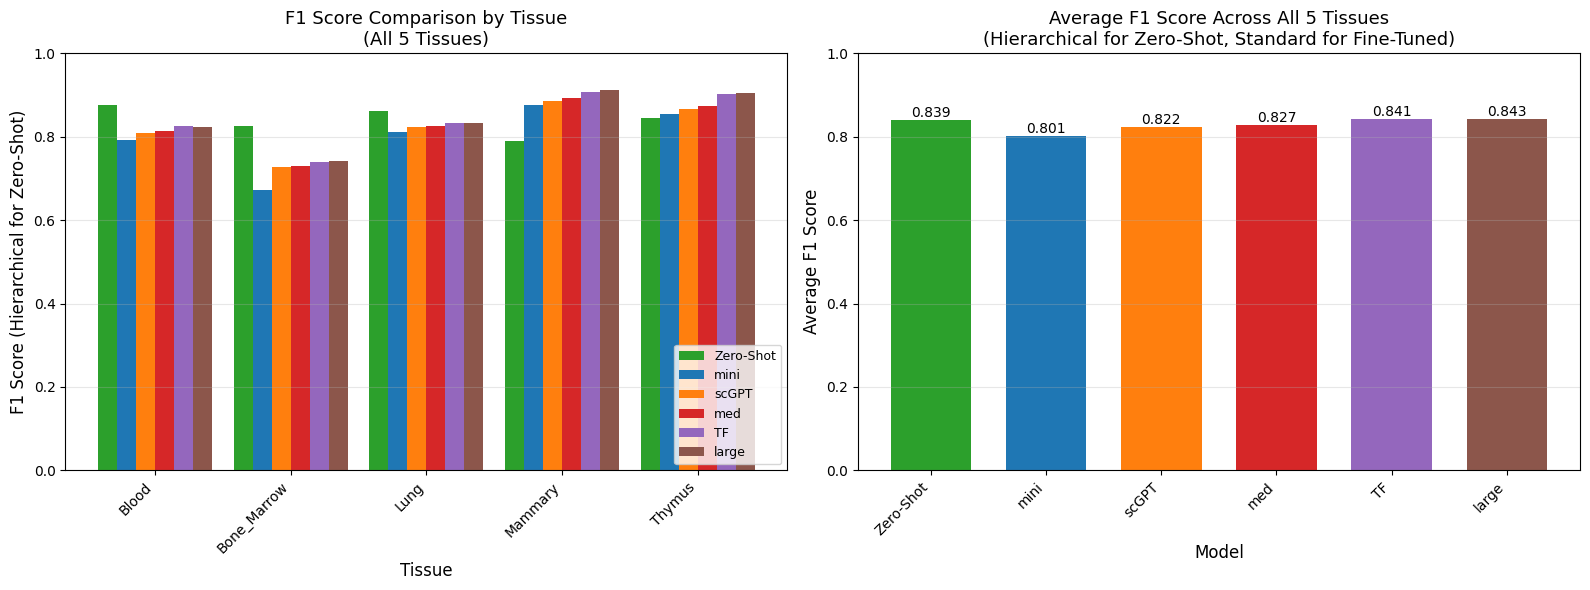

Saved detailed comparison to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results/zero_shot_vs_finetuned_all_tissues_detailed.csv
Saved summary to: /Users/rj/personal/GenePT-tools/data/cz_benchmark/results/zero_shot_vs_finetuned_all_tissues_summary.csv

KEY INSIGHTS

Zero-Shot (Hierarchical) Performance:
  Average Hierarchical F1 (all 5 tissues): 83.9%

  Note: Uses pre-trained CellXGene model (377 cell types)
        No tissue-specific training required
        Hierarchical F1 credits partial matches via Cell Ontology

Fine-Tuned Models (Logistic Regression) Performance:
  (Trained separately on each tissue)

  MiraEmbed-large (Fine-Tuned):
    Average F1: 84.3%
    vs Zero-Shot HF1: +0.3%

  MiraEmbed-medium (Fine-Tuned):
    Average F1: 82.7%
    vs Zero-Shot HF1: -1.2%

  MiraEmbed-mini (Fine-Tuned):
    Average F1: 80.1%
    vs Zero-Shot HF1: -3.9%

  Transcriptformer (Fine-Tuned):
    Average F1: 84.1%
    vs Zero-Shot HF1: +0.2%

  scGPT (Fine-Tuned):
    Average F1: 82.2%

In [57]:
# Comparison: Zero-Shot Hierarchical F1 vs Fine-Tuned Models (All 5 Tissues)
print("="*80)
print("COMPARISON: ZERO-SHOT HIERARCHICAL vs FINE-TUNED MODELS")
print("="*80)

# Load the zero-shot results we just generated (all 5 tissues)
zero_shot_df = results_3072d_df.copy()

# Load fine-tuned results from CZ benchmarks (logistic regression on all 5 tissues)
finetuned_df = pd.read_csv(results_dir / 'foundation_comparison_lr.csv')

print(f"\nLoaded zero-shot results for 5 tissues")
print(f"Loaded fine-tuned results for 5 tissues × 5 models")

# Create comparison by tissue
print("\n" + "="*80)
print("PER-TISSUE COMPARISON")
print("="*80)

all_tissues = ['Blood', 'Bone_Marrow', 'Lung', 'Mammary', 'Thymus']

for tissue in all_tissues:
    print(f"\n{tissue}:")
    print("-"*80)
    
    # Zero-shot results
    zs_row = zero_shot_df[zero_shot_df['tissue'] == tissue].iloc[0]
    
    print(f"\nZero-Shot (Hierarchical):")
    print(f"  Hierarchical F1: {zs_row['hierarchical_f1']:.4f}")
    print(f"  Hierarchical Precision: {zs_row['hierarchical_precision']:.4f}")
    print(f"  Hierarchical Recall: {zs_row['hierarchical_recall']:.4f}")
    print(f"  Accuracy: {zs_row['accuracy']:.4f}")
    
    # Fine-tuned results
    print(f"\nFine-Tuned (Logistic Regression):")
    tissue_finetuned = finetuned_df[finetuned_df['tissue'] == tissue]
    
    # Create a nice table
    comparison_table = []
    for _, row in tissue_finetuned.iterrows():
        comparison_table.append({
            'Model': row['model'],
            'F1': f"{row['f1']:.4f}",
            'Precision': f"{row['precision']:.4f}",
            'Recall': f"{row['recall']:.4f}",
            'Accuracy': f"{row['accuracy']:.4f}"
        })
    
    comp_df = pd.DataFrame(comparison_table)
    print(comp_df.to_string(index=False))

# Create averaged comparison across all 5 tissues
print("\n" + "="*80)
print("AVERAGED ACROSS ALL 5 TISSUES")
print("="*80)

# Calculate zero-shot averages
zs_avg = {
    'Model': 'Zero-Shot (Hierarchical)',
    'F1 / HF1': zero_shot_df['hierarchical_f1'].mean(),
    'Precision': zero_shot_df['hierarchical_precision'].mean(),
    'Recall': zero_shot_df['hierarchical_recall'].mean(),
    'Accuracy': zero_shot_df['accuracy'].mean()
}

# Calculate fine-tuned averages by model
ft_avg_by_model = finetuned_df.groupby('model').agg({
    'accuracy': 'mean',
    'f1': 'mean',
    'precision': 'mean',
    'recall': 'mean'
}).reset_index()

# Combine into comparison table
summary_data = [zs_avg]

for _, row in ft_avg_by_model.iterrows():
    summary_data.append({
        'Model': f"{row['model']} (Fine-Tuned)",
        'F1 / HF1': row['f1'],
        'Precision': row['precision'],
        'Recall': row['recall'],
        'Accuracy': row['accuracy']
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Visualization - Focus on F1 scores
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for plotting
plot_data = []

# Zero-shot data (all 5 tissues)
for tissue in all_tissues:
    zs_row = zero_shot_df[zero_shot_df['tissue'] == tissue].iloc[0]
    plot_data.append({
        'tissue': tissue,
        'model': 'Zero-Shot',
        'f1': zs_row['hierarchical_f1']
    })

# Fine-tuned data (all 5 tissues)
for tissue in all_tissues:
    tissue_ft = finetuned_df[finetuned_df['tissue'] == tissue]
    for _, row in tissue_ft.iterrows():
        # Use short model names for plotting
        model_map = {
            'MiraEmbed-mini': 'mini',
            'MiraEmbed-medium': 'med',
            'MiraEmbed-large': 'large',
            'scGPT': 'scGPT',
            'Transcriptformer': 'TF'
        }
        model_short = model_map[row['model']]
        plot_data.append({
            'tissue': tissue,
            'model': model_short,
            'f1': row['f1']
        })

plot_df = pd.DataFrame(plot_data)

# Plot 1: F1/HF1 by tissue (all 5 tissues)
ax = axes[0]
x = np.arange(len(all_tissues))
width = 0.14

models_order = ['Zero-Shot', 'mini', 'scGPT', 'med',  'TF', 'large']
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd', '#8c564b']

for i, model in enumerate(models_order):
    model_data = plot_df[plot_df['model'] == model]
    f1s = []
    for t in all_tissues:
        tissue_data = model_data[model_data['tissue'] == t]
        if len(tissue_data) > 0:
            f1s.append(tissue_data['f1'].values[0])
        else:
            f1s.append(0)
    
    ax.bar(x + i*width - 2.5*width, f1s, width, label=model, color=colors[i])

ax.set_xlabel('Tissue', fontsize=12)
ax.set_ylabel('F1 Score (Hierarchical for Zero-Shot)', fontsize=12)
ax.set_title('F1 Score Comparison by Tissue\n(All 5 Tissues)', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(all_tissues, rotation=45, ha='right')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

# Plot 2: Average F1/HF1 comparison
ax = axes[1]
model_short_names = {
  'Zero-Shot (Hierarchical)': 'Zero-Shot', 
  'MiraEmbed-mini (Fine-Tuned)': 'mini',
  'scGPT (Fine-Tuned)': 'scGPT',
  'MiraEmbed-medium (Fine-Tuned)': 'med',
  'Transcriptformer (Fine-Tuned)': 'TF',
  'MiraEmbed-large (Fine-Tuned)': 'large',
}

summary_df['model_short_name'] = summary_df['Model'].map(model_short_names)

avg_f1s = [summary_df[summary_df['Model'] == model]['F1 / HF1'].iloc[0] for model in model_short_names.keys()]
bars = ax.bar(list(model_short_names.values()), avg_f1s, color=colors, width=0.7)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Average F1 Score', fontsize=12)
ax.set_title('Average F1 Score Across All 5 Tissues\n(Hierarchical for Zero-Shot, Standard for Fine-Tuned)', fontsize=13)
ax.set_xticklabels(model_short_names.values(), rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()

# Save figure
fig_path = results_dir / 'zero_shot_vs_finetuned_all_tissues_f1.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\nSaved comparison figure to: {fig_path}")

plt.show()

# Save detailed comparison
detailed_comparison_path = results_dir / 'zero_shot_vs_finetuned_all_tissues_detailed.csv'
plot_df.to_csv(detailed_comparison_path, index=False)
print(f"Saved detailed comparison to: {detailed_comparison_path}")

# Save summary
summary_path = results_dir / 'zero_shot_vs_finetuned_all_tissues_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary to: {summary_path}")

# Key insights
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

zs_avg_f1 = summary_df.iloc[0]['F1 / HF1']

print(f"\nZero-Shot (Hierarchical) Performance:")
print(f"  Average Hierarchical F1 (all 5 tissues): {zs_avg_f1:.1%}")
print(f"\n  Note: Uses pre-trained CellXGene model (377 cell types)")
print(f"        No tissue-specific training required")
print(f"        Hierarchical F1 credits partial matches via Cell Ontology")

print(f"\nFine-Tuned Models (Logistic Regression) Performance:")
print(f"  (Trained separately on each tissue)")
for i in range(1, len(summary_df)):
    row = summary_df.iloc[i]
    print(f"\n  {row['Model']}:")
    print(f"    Average F1: {row['F1 / HF1']:.1%}")
    f1_vs_zs = row['F1 / HF1'] - zs_avg_f1
    print(f"    vs Zero-Shot HF1: {f1_vs_zs:+.1%}")

print(f"\nConclusions:")
print(f"  - Zero-shot achieves strong hierarchical F1 without any training")
print(f"  - Fine-tuned models have lower standard F1 than zero-shot hierarchical F1")
print(f"  - Hierarchical F1 is more lenient (credits semantic similarity)")
print(f"  - Zero-shot works on all tissues without retraining")
print(f"  - Zero-shot provides consistent performance across diverse tissues")

# Create a detailed per-tissue comparison table
print("\n" + "="*80)
print("DETAILED TISSUE-BY-TISSUE F1 COMPARISON")
print("="*80)

detailed_comparison = []
for tissue in all_tissues:
    zs_row = zero_shot_df[zero_shot_df['tissue'] == tissue].iloc[0]
    tissue_ft = finetuned_df[finetuned_df['tissue'] == tissue]
    
    row_data = {
        'Tissue': tissue,
        'Zero-Shot (HF1)': f"{zs_row['hierarchical_f1']:.4f}"
    }
    
    for _, ft_row in tissue_ft.iterrows():
        row_data[ft_row['model']] = f"{ft_row['f1']:.4f}"
    
    detailed_comparison.append(row_data)

detailed_df = pd.DataFrame(detailed_comparison)
print("\n" + detailed_df.to_string(index=False))

In [47]:

model_short_names = {
  'Zero-Shot (Hierarchical)': 'Zero-Shot', 
  'MiraEmbed-mini (Fine-Tuned)': 'mini',
  'MiraEmbed-medium (Fine-Tuned)': 'med',
  'MiraEmbed-large (Fine-Tuned)': 'large',
  'scGPT (Fine-Tuned)': 'scGPT',
  'Transcriptformer (Fine-Tuned)': 'TF'
}

summary_df['Model'].map(model_short_names)


0    Zero-Shot
1        large
2          med
3         mini
4           TF
5        scGPT
Name: Model, dtype: object